In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import re

In [2]:
# Paths
# -----------------------
PRESS_2018 = "2018_SCADA_Pressures.csv"
PRESS_2019 = "2019_SCADA_Pressures.csv"
FLOWS_2018 = "2018_SCADA_Flows.csv" 
FLOWS_2019 = "2019_SCADA_Flows.csv"    
LEVELS_2018 = "2018_SCADA_Levels.csv"
LEVELS_2019 = "2019_SCADA_Levels.csv"
DEMANDS_2018 = "2018_SCADA_Demands.csv"
DEMANDS_2019 = "2019_SCADA_Demands.csv"
LEAKS_2018 = "2018_Leakages.csv"
LEAKS_2019 = "2019_Leakages.csv"

In [3]:
# -----------------------
# 1) Robust CSV loader
#    (handles ; + decimal comma)
# -----------------------
def read_battledim_csv(path, timestamp_col="Timestamp"):
    df = pd.read_csv(path, sep=";", decimal=",")
    df.columns = df.columns.str.strip()

    s = df[timestamp_col].astype(str).str.strip()

    ts = pd.to_datetime(s, format="%d.%m.%Y %H:%M", errors="coerce")
    
    mask = ts.isna()
    ts.loc[mask] = pd.to_datetime(
        s[mask],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )

    mask = ts.isna()
    ts.loc[mask] = pd.to_datetime(
        s[mask],
        format="%Y-%m-%d %H:%M",
        errors="coerce"
    )

    df[timestamp_col] = ts
    return df

# -----------------------
# 2) rename columns in the dataset
#    change columns in dataset to be
#    more distinguished.
# -----------------------
def cols_rename(press, leak, flow):
    #pressure
    mapping = {}
    cols = press.columns.drop('Timestamp')
    mapping.update({old: f"press_{i+1}" for i, old in enumerate(cols)})
    press = press.rename(columns=mapping)

    #leak
    mapping = {}
    cols = leak.columns.drop('Timestamp')
    mapping.update({old: f"pipe_{i+1}" for i, old in enumerate(cols)})
    leak = leak.rename(columns=mapping)

    #flow
    mapping =  {}
    cols = flow.columns.drop('Timestamp')
    mapping.update({old: f"flow_{i+1}" for i, old in enumerate(cols)})
    flow = flow.rename(columns=mapping)

    return press, leak, flow

# -----------------------
# 3) Build labels from leak file
#    leak_binary: 1 if any pipe leak > 0 at timestamp
#    leak_count: number of leaking pipes at timestamp
#    leak_mag_total: sum of leak magnitudes
# -----------------------
def build_leak_labels(leaks_df):
    pipe_cols = [c for c in leaks_df.columns if c != "Timestamp"]
    labels = leaks_df.copy()
    # ensure numeric
    for c in pipe_cols:
        labels[c] = pd.to_numeric(labels[c], errors="coerce").fillna(0.0)
    # binary version of each pipe
    for c in pipe_cols:
        labels[c + "_bin"] = (labels[c] > 0).astype(int)

    # total magnitude
    labels["leak_mag_total"] = labels[pipe_cols].sum(axis=1)
    # number of leaking pipes
    labels["leak_count"] = (labels[pipe_cols] > 0).sum(axis=1)
    labels["leak_binary"] = (labels["leak_count"] > 0).astype(int)

    return labels[["Timestamp"] + [c+"_bin" for c in pipe_cols] + ["leak_mag_total","leak_count","leak_binary"]]


# -----------------------
# 4) Helper: shade leak periods on a plot
# -----------------------
def shade_leaks(ax, df, time_col="Timestamp", leak_col="leak_binary", alpha=0.15):
    t = df[time_col].values
    y = df[leak_col].values.astype(int)

    # Find contiguous leak segments
    in_leak = False
    start = None
    for i in range(len(y)):
        if y[i] == 1 and not in_leak:
            in_leak = True
            start = t[i]
        if in_leak and (y[i] == 0 or i == len(y)-1):
            end = t[i] if y[i] == 0 else t[i]
            ax.axvspan(start, end, alpha=alpha)
            in_leak = False

In [4]:
# -----------------------
# Load data
# -----------------------
press18 = read_battledim_csv(PRESS_2018)
press19 = read_battledim_csv(PRESS_2019)

flows18  = read_battledim_csv(FLOWS_2018)
flows19  = read_battledim_csv(FLOWS_2019)

levels18 = read_battledim_csv(LEVELS_2018)
levels19 = read_battledim_csv(LEVELS_2019)

demands18 = read_battledim_csv(DEMANDS_2018)
demands19 = read_battledim_csv(DEMANDS_2019)

leaks18 = read_battledim_csv(LEAKS_2018)
leaks19 = read_battledim_csv(LEAKS_2019)

In [5]:
demands19.isnull().sum()

Timestamp    0
n1           0
n2           0
n3           0
n4           0
            ..
n385         0
n386         0
n387         0
n388         0
n389         0
Length: 83, dtype: int64

In [6]:
press18

,Timestamp,n1,n4,n31,n54,n105,n114,n163,n188,n215,...,n549,n613,n636,n644,n679,n722,n726,n740,n752,n769
0,2018-01-01 00:00:00,28.92,33.87,37.13,37.13,50.52,53.99,52.56,55.32,39.09,...,54.80,56.16,45.53,47.62,47.33,46.14,47.12,43.81,49.17,48.50
1,2018-01-01 00:05:00,28.94,33.89,37.16,37.23,50.60,54.09,52.67,55.42,39.10,...,54.90,56.26,45.61,47.71,47.39,46.19,47.17,43.83,49.22,48.54
2,2018-01-01 00:10:00,28.96,33.91,37.18,37.21,50.57,54.05,52.64,55.39,39.09,...,54.87,56.24,45.61,47.71,47.41,46.20,47.19,43.84,49.24,48.56
3,2018-01-01 00:15:00,28.98,33.93,37.19,37.27,50.60,54.08,52.70,55.45,39.09,...,54.92,56.30,45.65,47.75,47.43,46.21,47.21,43.84,49.26,48.57
4,2018-01-01 00:20:00,28.98,33.93,37.19,37.14,50.53,54.00,52.57,55.32,39.09,...,54.80,56.17,45.54,47.64,47.34,46.15,47.13,43.81,49.17,48.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105115,2018-12-31 23:35:00,28.55,33.61,36.93,36.88,50.42,53.88,52.34,55.09,39.09,...,54.64,55.90,45.34,47.40,47.12,45.98,46.90,43.73,48.94,48.33
105116,2018-12-31 23:40:00,28.56,33.61,36.94,36.82,50.38,53.82,52.28,55.03,39.09,...,54.59,55.85,45.31,47.37,47.11,45.97,46.89,43.72,48.93,48.33
105117,2018-12-31 23:45:00,28.58,33.64,36.96,36.90,50.43,53.88,52.35,55.11,39.10,...,54.66,55.92,45.36,47.44,47.16,46.01,46.95,43.74,48.98,48.36
105118,2018-12-31 23:50:00,28.58,33.64,36.96,36.85,50.40,53.86,52.31,55.06,39.09,...,54.63,55.87,45.31,47.37,47.10,45.97,46.89,43.73,48.93,48.32


In [7]:
nans = press18.isna().sum()
print(type(nans))
with open("nans.txt", "w") as f:
        f.write(nans.to_string())

<class 'pandas.core.series.Series'>


In [8]:
press18, leaks18, flows18 = cols_rename(press18, leaks18, flows18)
press19, leaks19, flows19 = cols_rename(press19, leaks19, flows19)

In [9]:
nans = leaks19.isna().sum()
print(type(nans))
with open("nans.txt", "w") as f:
        f.write(nans.to_string())

<class 'pandas.core.series.Series'>


In [10]:
with open("demands.txt", "w") as f:
        f.write(levels19.isnull().sum().to_string())


In [11]:
# -----------------------
# merge data
# -----------------------
lab18 = build_leak_labels(leaks18)
lab19 = build_leak_labels(leaks19)


df18 = press18.merge(lab18, on="Timestamp", how="left")
df19 = press19.merge(lab19, on="Timestamp", how="left")

# for col in [ 'pipe_1_bin',
#        'pipe_2_bin', 'pipe_3_bin', 'pipe_4_bin', 'pipe_5_bin', 'pipe_6_bin',
#        'pipe_7_bin', 'pipe_8_bin', 'pipe_9_bin', 'pipe_10_bin', 'pipe_11_bin',
#        'pipe_12_bin', 'pipe_13_bin', 'pipe_14_bin', 'leak_mag_total',
#        'leak_count']:
#     df18[col] = df18[col].fillna(0)
#     df19[col] = df19[col].fillna(0)

df18_all = df18.copy()
df18_all = df18_all.merge(flows18, on="Timestamp", how="left")
df18_all = df18_all.merge(levels18, on="Timestamp", how="left")
df18_all = df18_all.merge(demands18, on="Timestamp", how="left")

df19_all = df19.copy()
# print("==========1===========\n", df19_all.isnull().sum())
df19_all = df19_all.merge(flows19, on="Timestamp", how="left")
# print("==========2===========\n", df19_all.isnull().sum())
# print(df19_all.head())
# print(levels19.head())
df19_all = df19_all.merge(levels19, on="Timestamp", how="left")
# print("==========3===========\n", df19_all.isnull().sum())

df19_all = df19_all.merge(demands19, on="Timestamp", how="left")
# print("==========4===========\n", df19_all.isnull().sum())

In [12]:
df19_all.isnull().sum()

Timestamp    0
press_1      0
press_2      0
press_3      0
press_4      0
            ..
n385         0
n386         0
n387         0
n388         0
n389         0
Length: 137, dtype: int64

In [13]:
df18_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105120 entries, 0 to 105119
Columns: 137 entries, Timestamp to n389
dtypes: datetime64[ns](1), float64(120), int64(16)
memory usage: 109.9 MB


In [14]:
df18_all.describe()

,Timestamp,press_1,press_2,press_3,press_4,press_5,press_6,press_7,press_8,press_9,...,n379,n381,n382,n383,n384,n385,n386,n387,n388,n389
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,...,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000
mean,2018-07-02 11:57:29.999999744,28.177514,33.264552,36.604953,36.796791,50.243409,53.659096,52.139037,54.889171,39.081582,...,93.271990,218.204332,150.410525,83.253823,229.934689,47.964023,266.143119,159.159848,443.478494,166.297643
min,2018-01-01 00:00:00,25.670000,30.900000,34.590000,34.330000,48.770000,51.970000,49.770000,52.480000,38.890000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-04-02 05:58:45,27.740000,32.840000,36.190000,36.190000,49.990000,53.370000,51.680000,54.450000,39.080000,...,38.050000,86.920000,61.420000,33.027500,82.350000,17.850000,108.050000,60.740000,242.817500,64.640000
50%,2018-07-02 11:57:30,28.100000,33.200000,36.550000,36.810000,50.210000,53.620000,52.100000,54.850000,39.090000,...,87.210000,203.250000,139.850000,77.360000,215.850000,44.800000,249.070000,148.685000,430.325000,155.050000
75%,2018-10-01 17:56:15,28.630000,33.720000,37.030000,37.370000,50.520000,53.980000,52.610000,55.360000,39.090000,...,137.640000,322.780000,221.370000,122.910000,345.870000,71.960000,392.510000,237.602500,612.542500,246.315000
max,2018-12-31 23:55:00,29.360000,34.310000,37.570000,38.290000,50.950000,54.490000,53.350000,56.080000,39.100000,...,303.520000,743.970000,520.820000,292.040000,791.320000,164.590000,906.240000,530.300000,1352.210000,573.620000
std,NaN,0.548432,0.541586,0.508478,0.739204,0.358803,0.420987,0.606962,0.600544,0.030324,...,62.898075,149.227010,102.201332,57.206987,164.243866,33.684873,180.440554,110.982410,238.488128,115.523757


In [15]:
# -----------------------
# EDA Graphs
# -----------------------

# (A) Time series with leak shading (choose a time window)
def plot_timeseries_with_leaks(df, sensor_col, start=None, end=None, title=None):
    d = df.copy()
    if start:
        d = d[d["Timestamp"] >= pd.to_datetime(start)]
    if end:
        d = d[d["Timestamp"] <= pd.to_datetime(end)]

    plt.figure()
    plt.plot(d["Timestamp"], d[sensor_col])
    ax = plt.gca()
    shade_leaks(ax, d)
    plt.title(title or f"{sensor_col} over time (leaks shaded)")
    plt.xlabel("Time")
    plt.ylabel(sensor_col)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# (B) Rolling mean/std
def plot_rolling(df, sensor_col, window="24H", start=None, end=None):
    d = df.set_index("Timestamp")[[sensor_col, "leak_binary"]].copy()
    if start:
        d = d[d.index >= pd.to_datetime(start)]
    if end:
        d = d[d.index <= pd.to_datetime(end)]

    # Convert window like "24H" to number of samples using inferred freq might be messy;
    # easier: rolling by time offset (works because index is datetime)
    roll_mean = d[sensor_col].rolling(window).mean()
    roll_std  = d[sensor_col].rolling(window).std()

    plt.figure()
    plt.plot(d.index, d[sensor_col], label="raw")
    plt.plot(d.index, roll_mean, label=f"rolling mean ({window})")
    plt.plot(d.index, roll_std, label=f"rolling std ({window})")
    ax = plt.gca()
    shade_leaks(ax, d.reset_index())
    plt.title(f"{sensor_col}: raw + rolling stats (leaks shaded)")
    plt.xlabel("Time")
    plt.ylabel(sensor_col)
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# (C) Leak vs No-leak boxplot (distribution shift)
def boxplot_leak_vs_noleak(df, sensor_col):
    leak_vals = df.loc[df["leak_binary"]==1, sensor_col].dropna()
    ok_vals   = df.loc[df["leak_binary"]==0, sensor_col].dropna()

    plt.figure()
    plt.boxplot([ok_vals.values, leak_vals.values], labels=["No leak", "Leak"])
    plt.title(f"{sensor_col} distribution: leak vs no-leak")
    plt.ylabel(sensor_col)
    plt.tight_layout()
    plt.show()

# (D) Pressure derivative histogram (ΔP)
def derivative_hist(df, sensor_col, label=None):
    if label == None:
        label = "leak_binary"

    d = df[["Timestamp", sensor_col, label]].copy()
    d["dP"] = d[sensor_col].diff()

    plt.figure()
    plt.hist(d.loc[d[label]==0, "dP"].dropna(), bins=80, alpha=0.6, label="No leak")
    plt.hist(d.loc[d[label]==1, "dP"].dropna(), bins=80, alpha=0.6, label="Leak")
    plt.title(f"Δ{sensor_col} (1-step difference) histogram")
    plt.xlabel("ΔP")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

# (E) Correlation heatmap (pressures only)
def corr_heatmap(df, cols, title="Correlation heatmap"):
    corr = df[cols].corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# (F) Hour-of-day pattern (daily cycles)
def hourly_pattern(df, sensor_col):
    d = df[["Timestamp", sensor_col]].dropna().copy()
    d["hour"] = d["Timestamp"].dt.hour
    agg = d.groupby("hour")[sensor_col].mean()

    plt.figure()
    plt.plot(agg.index, agg.values, marker="o")
    plt.title(f"{sensor_col} average by hour of day")
    plt.xlabel("Hour of day")
    plt.ylabel(f"Mean {sensor_col}")
    plt.xticks(range(0,24))
    plt.tight_layout()
    plt.show()

# (G) Leak frequency / imbalance
def plot_imbalance(df, label=None):
    if label==None:
        label = "leak_binary"

    rate = df[label].mean()
    plt.figure()
    plt.bar(["No leak", "Leak"], [(df[label]==0).sum(), (df[label]==1).sum()])
    plt.title(f"Class imbalance (Leak rate = {rate:.4f})")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# (H) Leak duration & magnitude (from label series)
def leak_stats_plots(df):
    d = df[["Timestamp", "leak_binary", "leak_mag_total", "leak_count"]].copy()
    d = d.sort_values("Timestamp").reset_index(drop=True)

    # durations in number of time steps
    durations = []
    mags = []
    counts = []

    in_leak = False
    start_idx = None
    for i in range(len(d)):
        if d.loc[i, "leak_binary"] == 1 and not in_leak:
            in_leak = True
            start_idx = i
        if in_leak and (d.loc[i, "leak_binary"] == 0 or i == len(d)-1):
            end_idx = i if d.loc[i, "leak_binary"] == 0 else i
            seg = d.loc[start_idx:end_idx]
            durations.append(len(seg))
            mags.append(seg["leak_mag_total"].max())
            counts.append(seg["leak_count"].max())
            in_leak = False

    if len(durations) == 0:
        print("No leak segments found in this dataframe.")
        return

    plt.figure()
    plt.hist(durations, bins=40)
    plt.title("Leak segment durations (in samples)")
    plt.xlabel("Duration (#rows)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.hist(mags, bins=40)
    plt.title("Leak magnitude (max per segment)")
    plt.xlabel("Max leak magnitude")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.hist(counts, bins=20)
    plt.title("Max simultaneous leak count per segment")
    plt.xlabel("Leak count")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# (I) PCA (pressures only) colored by leak/no-leak
def pca_plot(df, feature_cols, label_col="leak_binary", max_points=50000):
    print(feature_cols)
    print(label_col)
    d = df[feature_cols + [label_col]].dropna().copy()

    # subsample for speed
    if len(d) > max_points:
        d = d.sample(max_points, random_state=42)

    X = d[feature_cols].values
    y = d[label_col].values.astype(int)

    Xs = StandardScaler().fit_transform(X)
    pcs = PCA(n_components=2, random_state=42).fit_transform(Xs)
    
    plt.figure()
    plt.scatter(pcs[y==0, 0], pcs[y==0, 1], s=6, alpha=0.4, label="No leak")
    plt.scatter(pcs[y==1, 0], pcs[y==1, 1], s=6, alpha=0.6, label="Leak")
    plt.title("PCA of pressure sensors (2D)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [16]:
print(df18["leak_binary"].shape)

(105120,)


['press_1', 'press_2', 'press_3']
Example pressure columns: ['press_1', 'press_2', 'press_3']


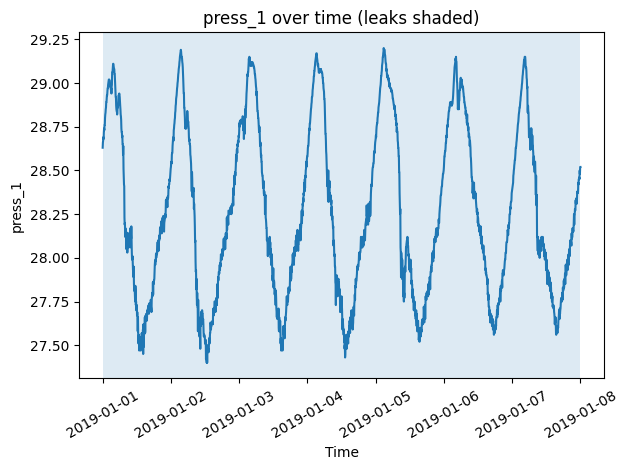

C:\Users\wari\AppData\Local\Temp\ipykernel_18160\2442334887.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  roll_mean = d[sensor_col].rolling(window).mean()
C:\Users\wari\AppData\Local\Temp\ipykernel_18160\2442334887.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  roll_std  = d[sensor_col].rolling(window).std()


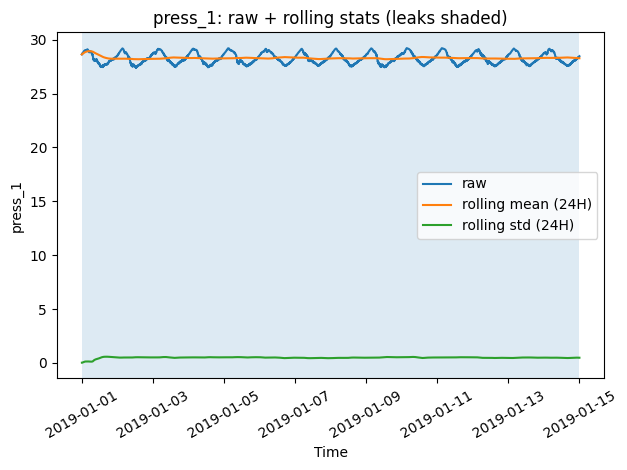

C:\Users\wari\AppData\Local\Temp\ipykernel_18160\2442334887.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ok_vals.values, leak_vals.values], labels=["No leak", "Leak"])


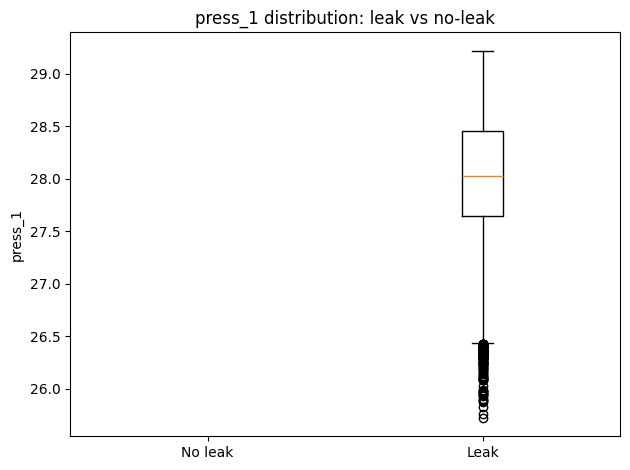

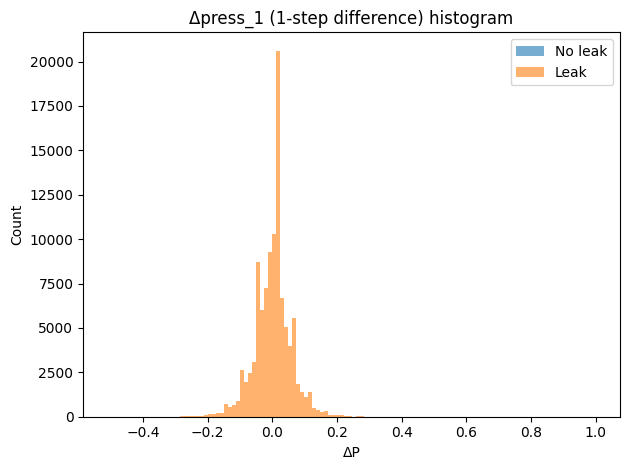

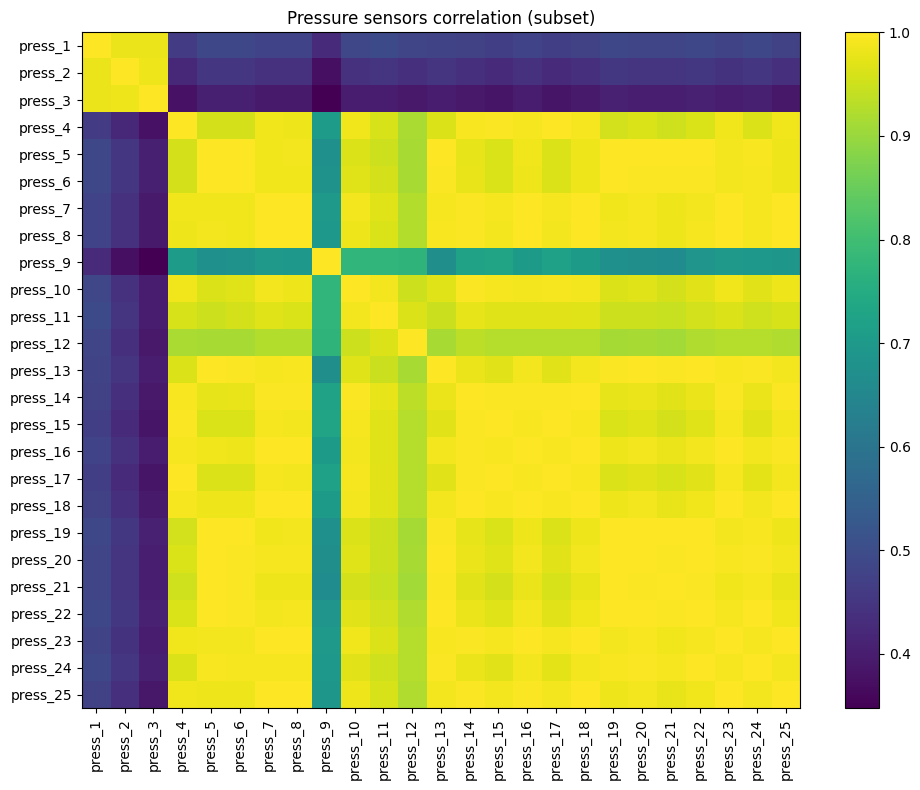

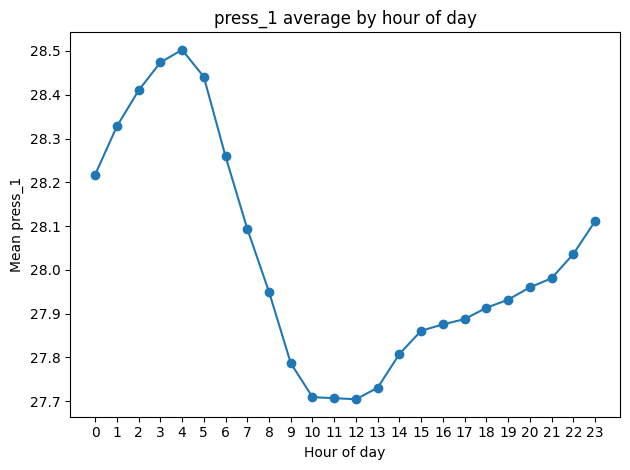

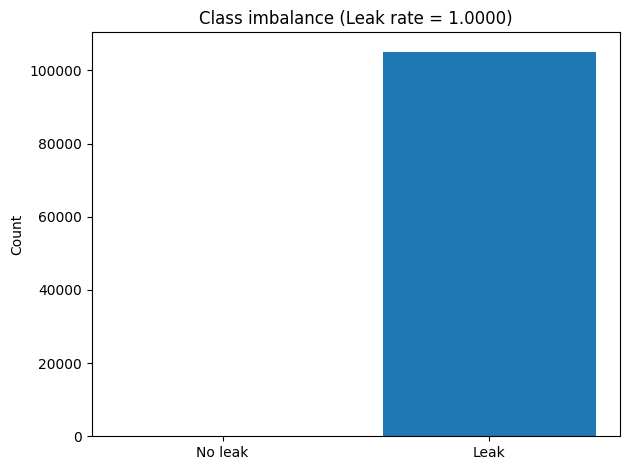

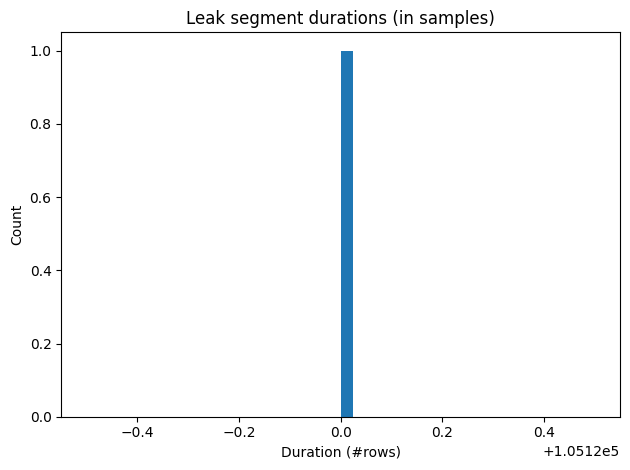

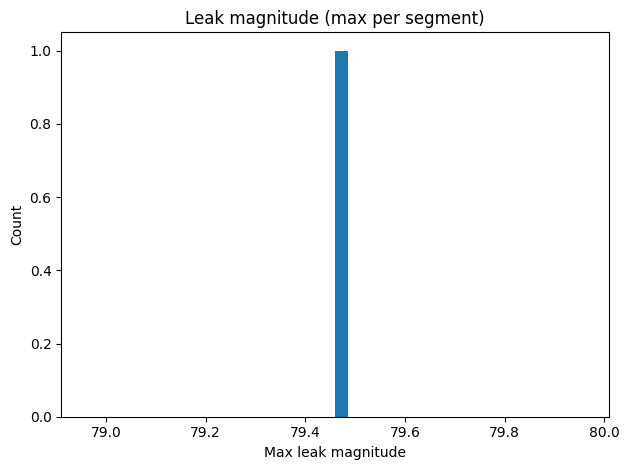

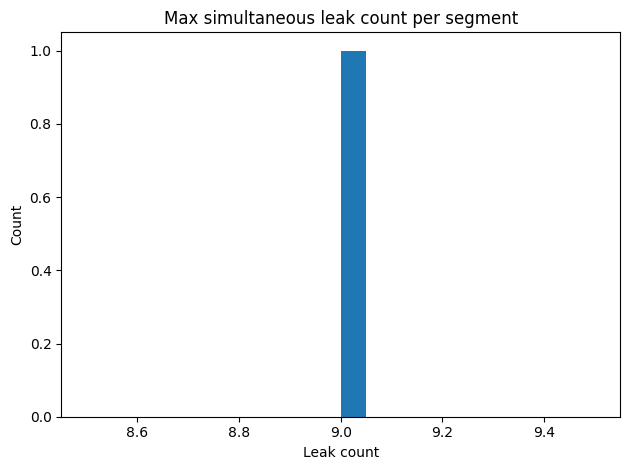

['press_1', 'press_2', 'press_3', 'press_4', 'press_5', 'press_6', 'press_7', 'press_8', 'press_9', 'press_10', 'press_11', 'press_12', 'press_13', 'press_14', 'press_15', 'press_16', 'press_17', 'press_18', 'press_19', 'press_20', 'press_21', 'press_22', 'press_23', 'press_24', 'press_25', 'press_26', 'press_27', 'press_28', 'press_29', 'press_30', 'press_31', 'press_32', 'press_33']
leak_binary


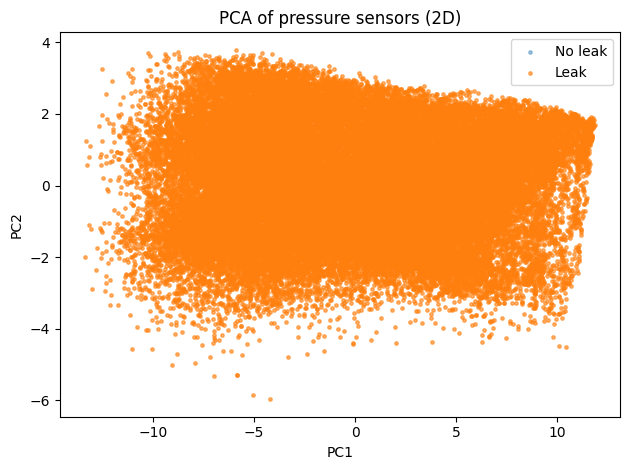

In [17]:
plot_df = df19 
pressure_cols = [c for c in plot_df.columns if c.startswith("press_")]
pick = pressure_cols[:3]  # first 3
print(pick)
print("Example pressure columns:", pick)

# Example: first week
plot_timeseries_with_leaks(plot_df, pick[0], start="2019-01-01", end="2019-01-08")
plot_rolling(plot_df, pick[0], window="24H", start="2019-01-01", end="2019-01-15")

boxplot_leak_vs_noleak(plot_df, pick[0])
derivative_hist(plot_df, pick[0])
corr_heatmap(plot_df, pressure_cols[:25], title="Pressure sensors correlation (subset)")
hourly_pattern(plot_df, pick[0])
plot_imbalance(plot_df)
leak_stats_plots(plot_df)
pca_plot(df=plot_df, feature_cols=pressure_cols, label_col="leak_binary")

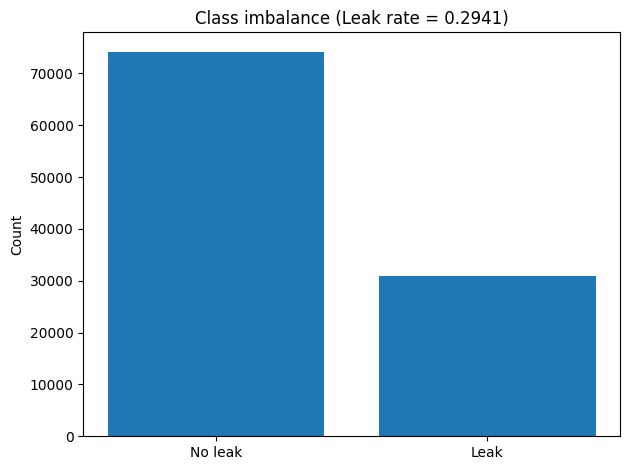

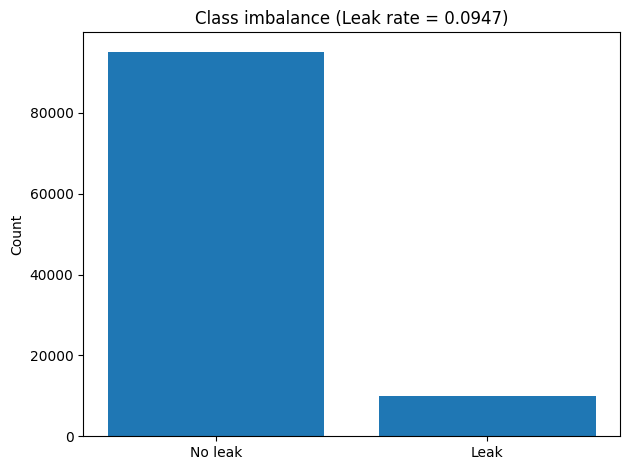

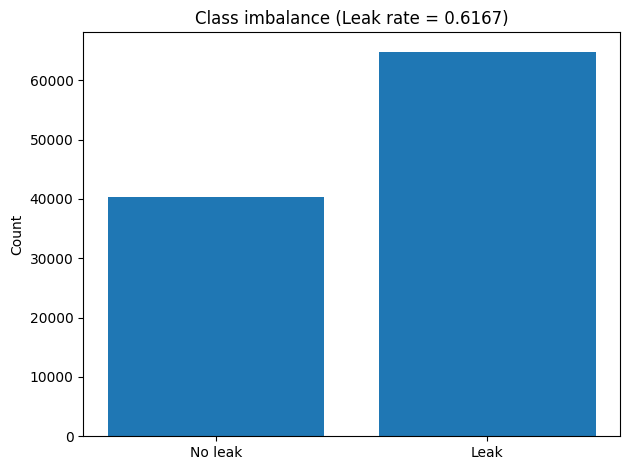

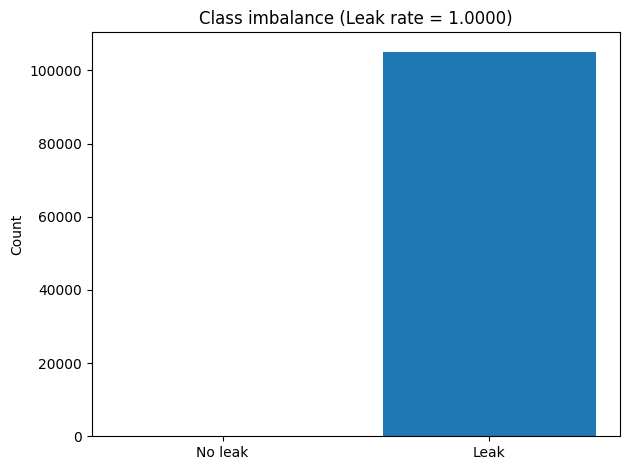

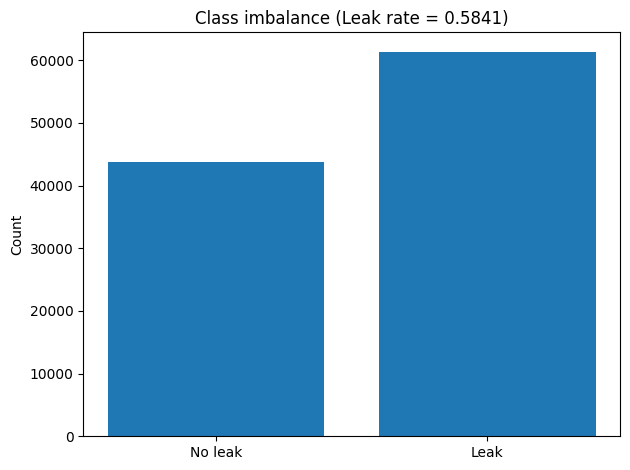

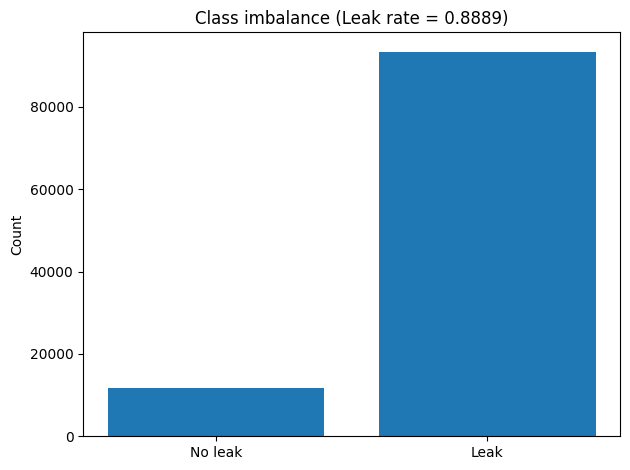

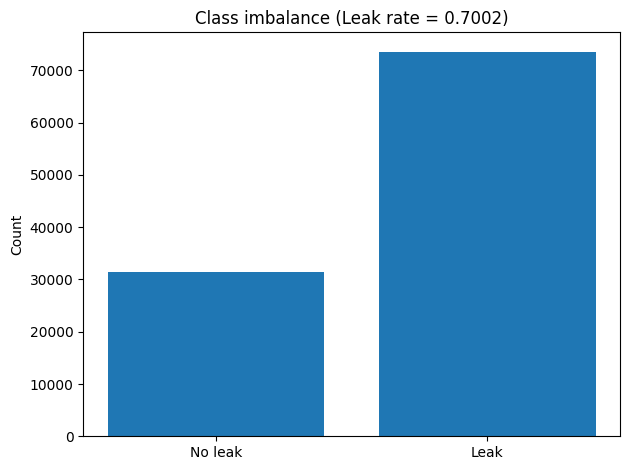

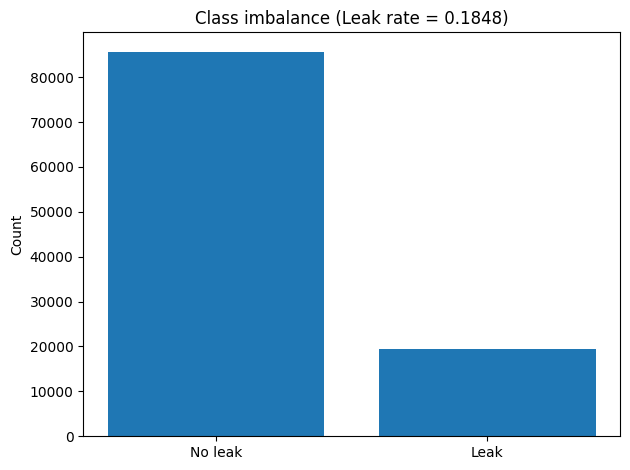

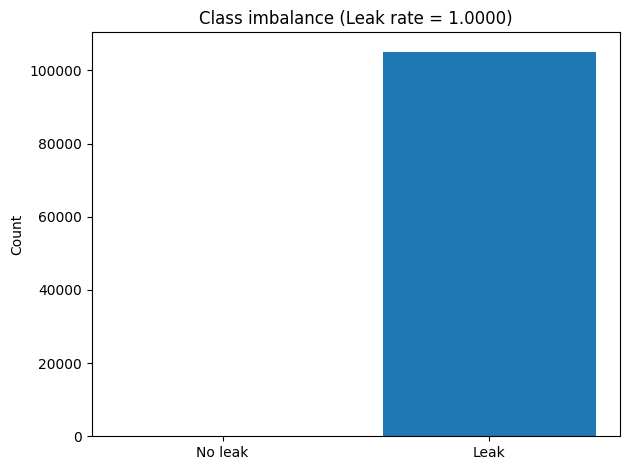

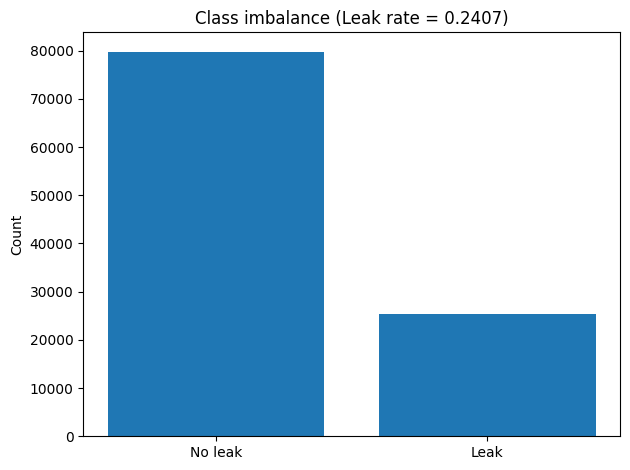

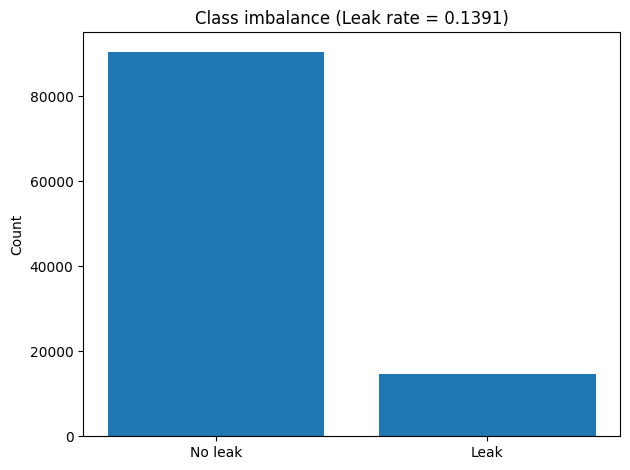

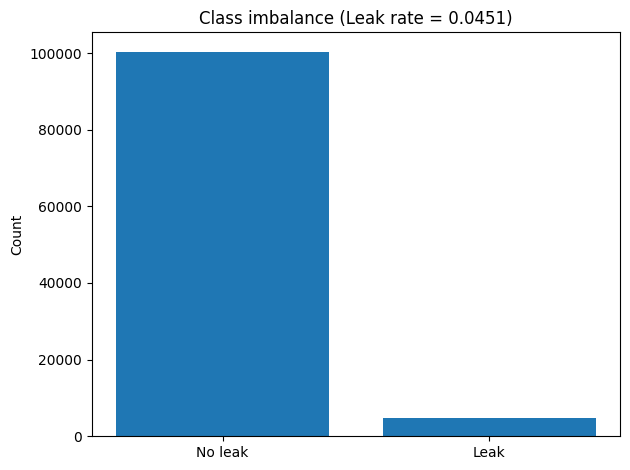

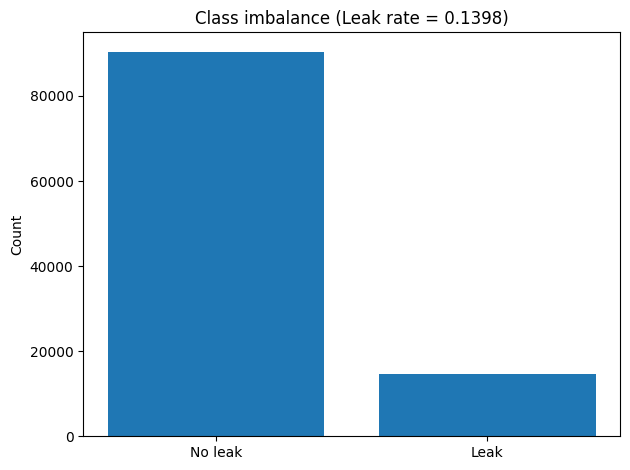

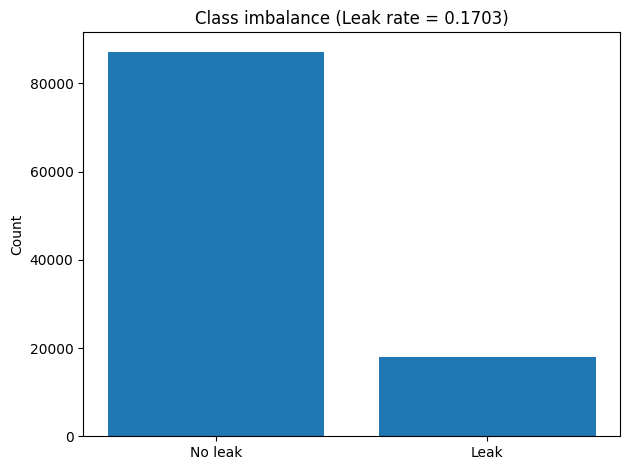

In [18]:
bins = ["pipe_1_bin","pipe_2_bin","pipe_3_bin","pipe_4_bin","pipe_5_bin","pipe_6_bin","pipe_7_bin",
"pipe_8_bin","pipe_9_bin","pipe_10_bin","pipe_11_bin","pipe_12_bin","pipe_13_bin","pipe_14_bin"]
for bin in bins:
    plot_imbalance(plot_df, label=bin)

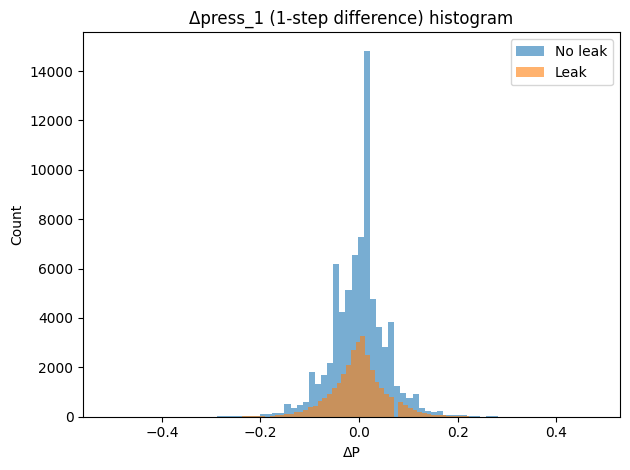

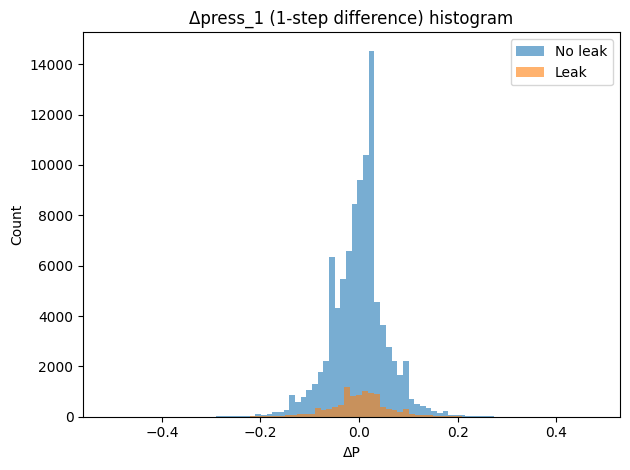

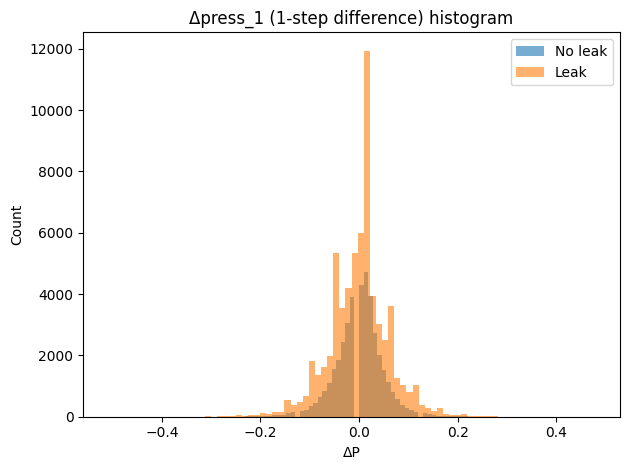

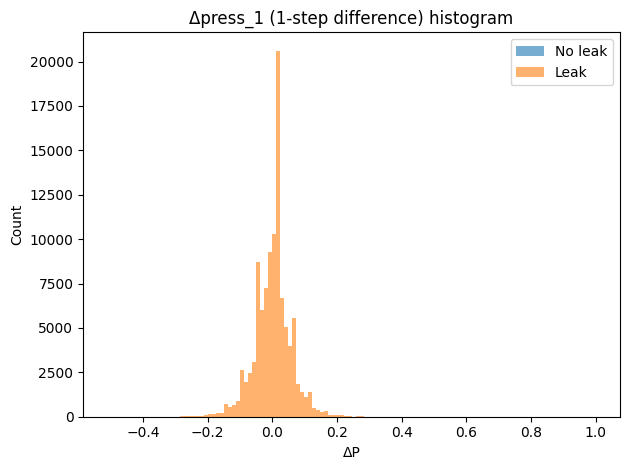

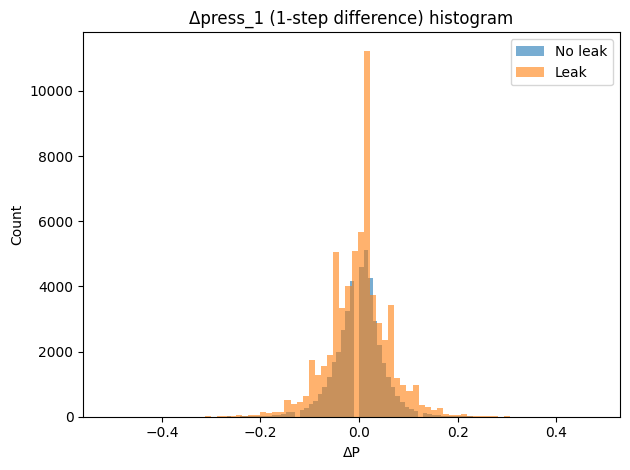

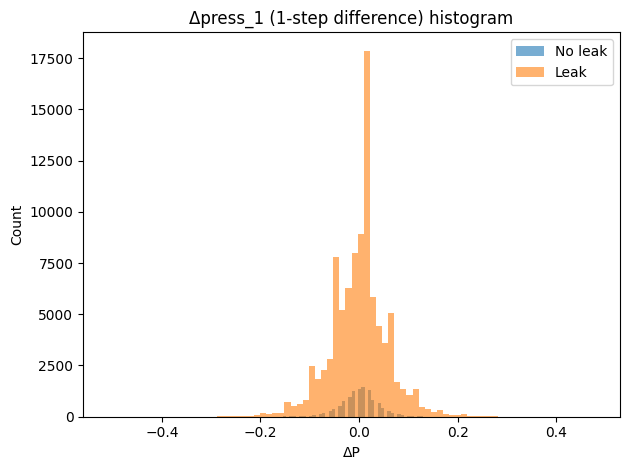

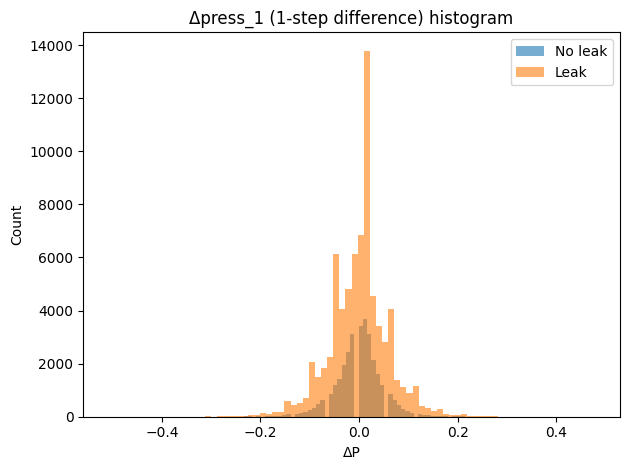

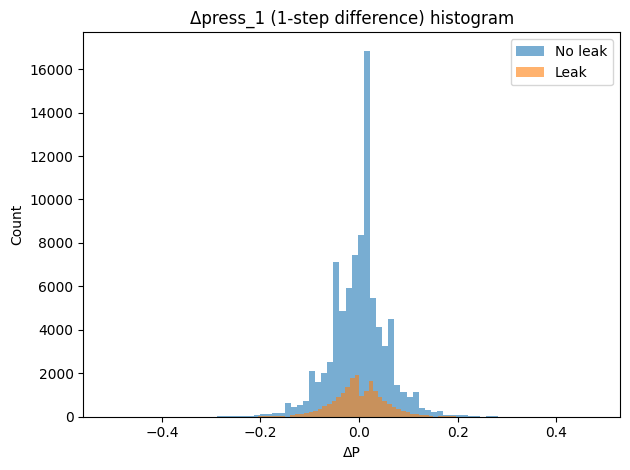

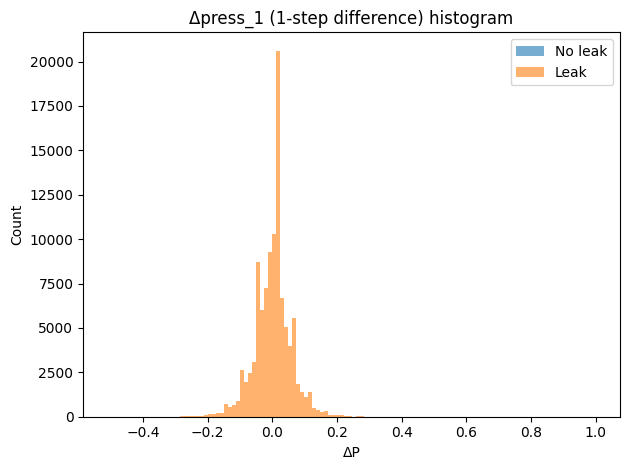

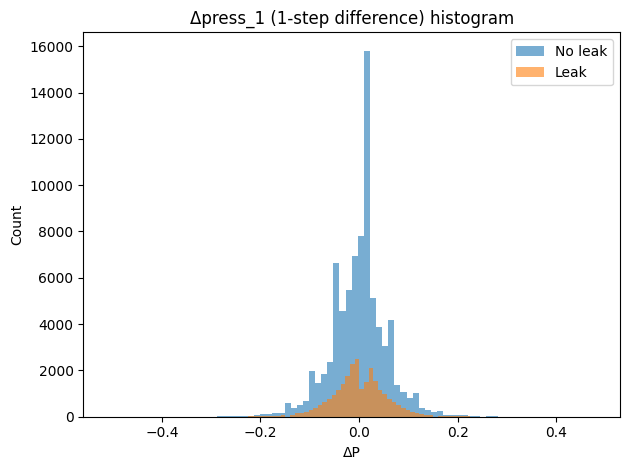

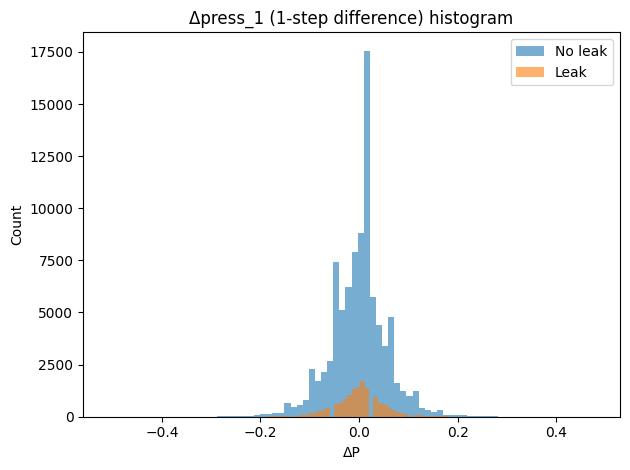

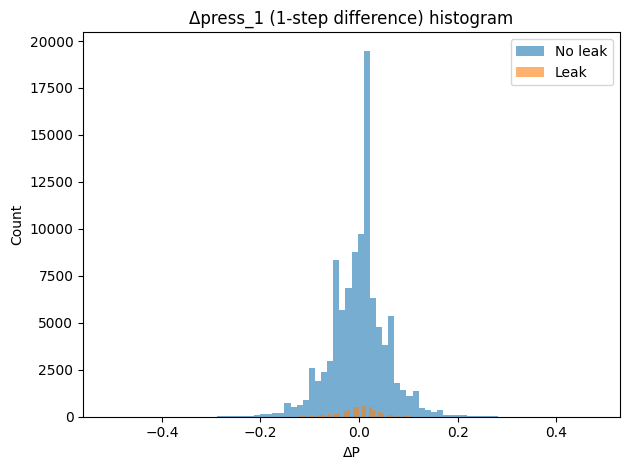

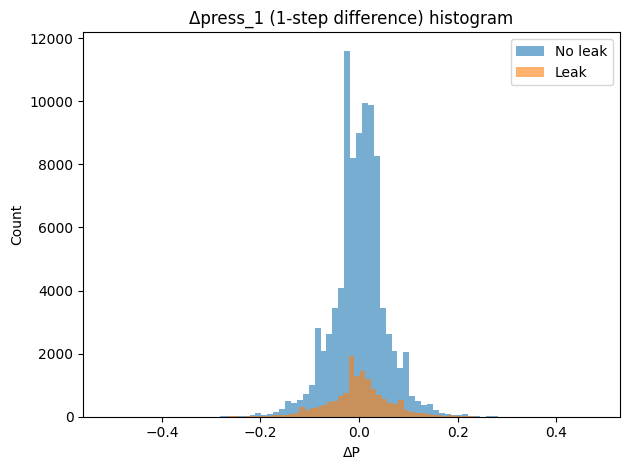

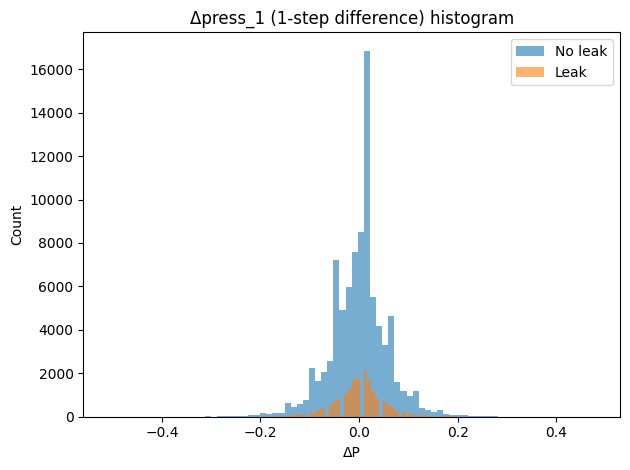

In [19]:
bins = ["pipe_1_bin","pipe_2_bin","pipe_3_bin","pipe_4_bin","pipe_5_bin","pipe_6_bin","pipe_7_bin",
"pipe_8_bin","pipe_9_bin","pipe_10_bin","pipe_11_bin","pipe_12_bin","pipe_13_bin","pipe_14_bin"]
for bin in bins:
    derivative_hist(plot_df, pick[0],label=bin)



In [30]:
full_data = pd.concat([df18_all, df19_all], ignore_index=True)

with open("columns_all.txt", "w") as f:
    for col in full_data.columns:
        f.write(col + "\n")
        

In [32]:
df19.shape


(105120, 51)

In [34]:
cols = full_data.columns

with open("cols.txt", "w") as f:
        for col in cols:
                f.write(col+'\n')

In [35]:
len(full_data.columns)

137

In [36]:
print('shape', full_data["leak_binary"].shape)
print(df19["leak_binary"].value_counts())
print(df19["leak_binary"].value_counts(dropna=False))
print("missing:", full_data["leak_binary"].isna().sum())
print("missing:", full_data["leak_count"].isna().sum())

shape (210240,)
leak_binary
1    105120
Name: count, dtype: int64
leak_binary
1    105120
Name: count, dtype: int64
missing: 0
missing: 0


In [38]:
full_data.to_csv('data_full_2018_2019_fixed.csv', index=False)
